In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [2]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, gain=None, left=None, right=None, value=None):
        # Decision Node
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.gain = gain
        self.left = left
        self.right = right
        # Leaf Node
        self.value = value

In [3]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=5, algorithm='CART'):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.algorithm = algorithm # 'ID3', 'C4.5', or 'CART'
        self.root = None

    def build_tree(self, dataset, curr_depth=0):
        X, y = dataset[:, :-1], dataset[:, -1]
        n_samples, n_features = X.shape

        if n_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.get_best_split(dataset, n_features)

            if best_split["gain"] > 0:
                left_node = self.build_tree(best_split["left_dataset"], curr_depth + 1)
                right_node = self.build_tree(best_split["right_dataset"], curr_depth + 1)
                return Node(best_split["feature_idx"], best_split["threshold"], 
                            best_split["gain"], left_node, right_node)

        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    def get_best_split(self, dataset, n_features):
        best_split = {'gain': -1}
        max_gain = -float("inf")

        for feature_idx in range(n_features):
            feature_values = dataset[:, feature_idx]
            thresholds = np.unique(feature_values)

            for threshold in thresholds:
                left_dataset, right_dataset = self.split(dataset, feature_idx, threshold)

                if len(left_dataset) > 0 and len(right_dataset) > 0:
                    y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]
                    
                    gain = self.calculate_gain(y, left_y, right_y)

                    if gain > max_gain:
                        best_split['feature_idx'] = feature_idx
                        best_split['threshold'] = threshold
                        best_split['gain'] = gain
                        best_split['left_dataset'] = left_dataset
                        best_split['right_dataset'] = right_dataset
                        max_gain = gain

        return best_split

    def split(self, dataset, feature_idx, threshold):
        left_dataset = dataset[dataset[:, feature_idx] <= threshold]
        right_dataset = dataset[dataset[:, feature_idx] > threshold]
        return left_dataset, right_dataset

    def calculate_gain(self, parent_y, left_y, right_y):
        weight_l = len(left_y) / len(parent_y)
        weight_r = len(right_y) / len(parent_y)

        if self.algorithm == 'CART':
            # Gini Gain
            p_gini = self.gini(parent_y)
            l_gini = self.gini(left_y)
            r_gini = self.gini(right_y)
            return p_gini - (weight_l * l_gini + weight_r * r_gini)

        elif self.algorithm == 'ID3':
            # Information Gain (Entropy)
            p_ent = self.entropy(parent_y)
            l_ent = self.entropy(left_y)
            r_ent = self.entropy(right_y)
            return p_ent - (weight_l * l_ent + weight_r * r_ent)

        elif self.algorithm == 'C4.5':
            # Gain Ratio
            p_ent = self.entropy(parent_y)
            l_ent = self.entropy(left_y)
            r_ent = self.entropy(right_y)
            info_gain = p_ent - (weight_l * l_ent + weight_r * r_ent)
            
            # Split Information
            split_info = -(weight_l * np.log2(weight_l + 1e-9) + weight_r * np.log2(weight_r + 1e-9))
            return info_gain / (split_info + 1e-9) # Avoid division by zero

    def entropy(self, y):
        class_labels = np.unique(y)
        ent = 0
        for cls in class_labels:
            p = len(y[y == cls]) / len(y)
            ent += -p * np.log2(p)
        return ent

    def gini(self, y):
        class_labels = np.unique(y)
        gini = 1
        for cls in class_labels:
            p = len(y[y == cls]) / len(y)
            gini -= p ** 2
        return gini

    def fit(self, X, y):
        start_time = time.time()
        dataset = np.column_stack((X, y))
        self.root = self.build_tree(dataset)
        train_time = time.time() - start_time
        return train_time

    def predict(self, X):
        return [self.predict_class(row, self.root) for row in X]

    def predict_class(self, row, node):
        if node.value is not None:
            return node.value
        if row[node.feature_idx] <= node.threshold:
            return self.predict_class(row, node.left)
        return self.predict_class(row, node.right)
        
    def get_depth(self, node=None):
        if node is None: node = self.root
        if node.value is not None: return 0
        return 1 + max(self.get_depth(node.left), self.get_depth(node.right))
        
    def get_n_leaves(self, node=None):
        if node is None: node = self.root
        if node.value is not None: return 1
        return self.get_n_leaves(node.left) + self.get_n_leaves(node.right)


# ==========================================
# 2. Evaluation Metrics (From Scratch)
# ==========================================
def calculate_metrics(y_true, y_pred):
    classes = np.unique(y_true)
    metrics = {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0}
    
    # Accuracy
    metrics['accuracy'] = np.mean(y_true == y_pred)
    
    # Macro-averaged Precision, Recall, F1
    precisions, recalls, f1s = [], [], []
    for c in classes:
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        
    metrics['precision'] = np.mean(precisions)
    metrics['recall'] = np.mean(recalls)
    metrics['f1'] = np.mean(f1s)
    
    return metrics


# ==========================================
# 3. Execution and Comparison
# ==========================================
if __name__ == "__main__":
    # Load Iris dataset
    iris = load_iris()
    X, y = iris.data, iris.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    algorithms = ['ID3', 'C4.5', 'CART']
    results = []

    for algo in algorithms:
        tree = DecisionTree(max_depth=5, algorithm=algo)
        
        # Train
        train_time = tree.fit(X_train, y_train)
        
        # Predict
        y_pred = tree.predict(X_test)
        
        # Evaluate metrics
        metrics = calculate_metrics(y_test, y_pred)
        
        # Tree Structure
        depth = tree.get_depth()
        leaves = tree.get_n_leaves()
        
        results.append({
            'Algorithm': algo,
            'Accuracy': f"{metrics['accuracy']:.4f}",
            'Precision': f"{metrics['precision']:.4f}",
            'Recall': f"{metrics['recall']:.4f}",
            'F1 Score': f"{metrics['f1']:.4f}",
            'Tree Depth': depth,
            'Leaf Nodes': leaves,
            'Train Time (s)': f"{train_time:.5f}"
        })

    # Print Results
    results_df = pd.DataFrame(results)
    print("\n--- Decision Tree Algorithm Comparison ---")
    print(results_df.to_string(index=False))


--- Decision Tree Algorithm Comparison ---
Algorithm Accuracy Precision Recall F1 Score  Tree Depth  Leaf Nodes Train Time (s)
      ID3   1.0000    1.0000 1.0000   1.0000           5           9        0.34019
     C4.5   1.0000    1.0000 1.0000   1.0000           5           9        0.23406
     CART   1.0000    1.0000 1.0000   1.0000           5           9        0.25120



--- Decision Tree Algorithm Comparison ---
Algorithm  Accuracy  Precision  Recall  F1 Score  Tree Depth  Leaf Nodes
      ID3       1.0        1.0     1.0       1.0           4           7
     C4.5       1.0        1.0     1.0       1.0           4           7
     CART       1.0        1.0     1.0       1.0           4           7

=== TEXT DESIGN ARCHITECTURE MAP (CART TREE) ===
├── Split rules: If petal length (cm) <= 1.90 (Gain Evaluated: 0.3334)
    [True Branch Split] └── Predict Class Label: 0
    [False Branch Split] ├── Split rules: If petal length (cm) <= 4.70 (Gain Evaluated: 0.3649)
        [True Branch Split] ├── Split rules: If petal width (cm) <= 1.60 (Gain Evaluated: 0.0526)
        |   [True Branch Split] └── Predict Class Label: 1
        |   [False Branch Split] └── Predict Class Label: 2
        [False Branch Split] ├── Split rules: If petal width (cm) <= 1.70 (Gain Evaluated: 0.0673)
            [True Branch Split] ├── Split rules: If petal length (cm) <= 4.90 (G

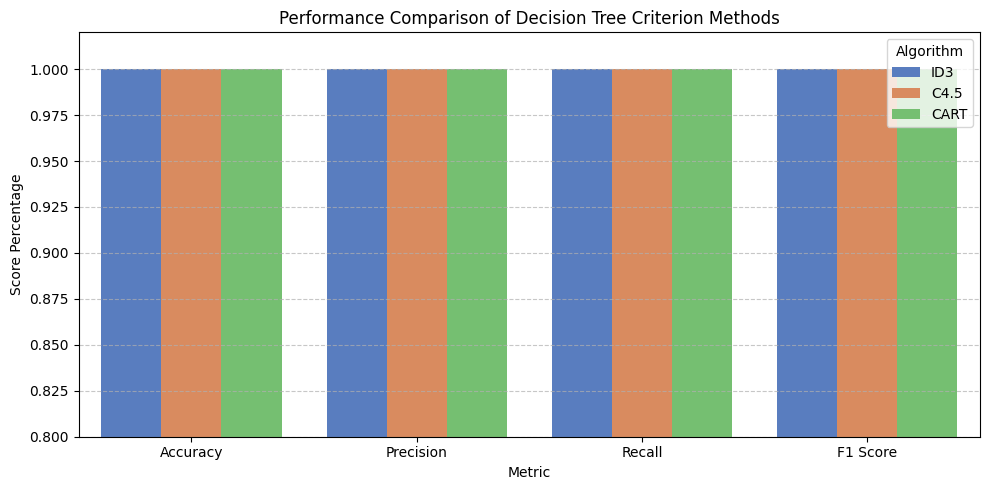

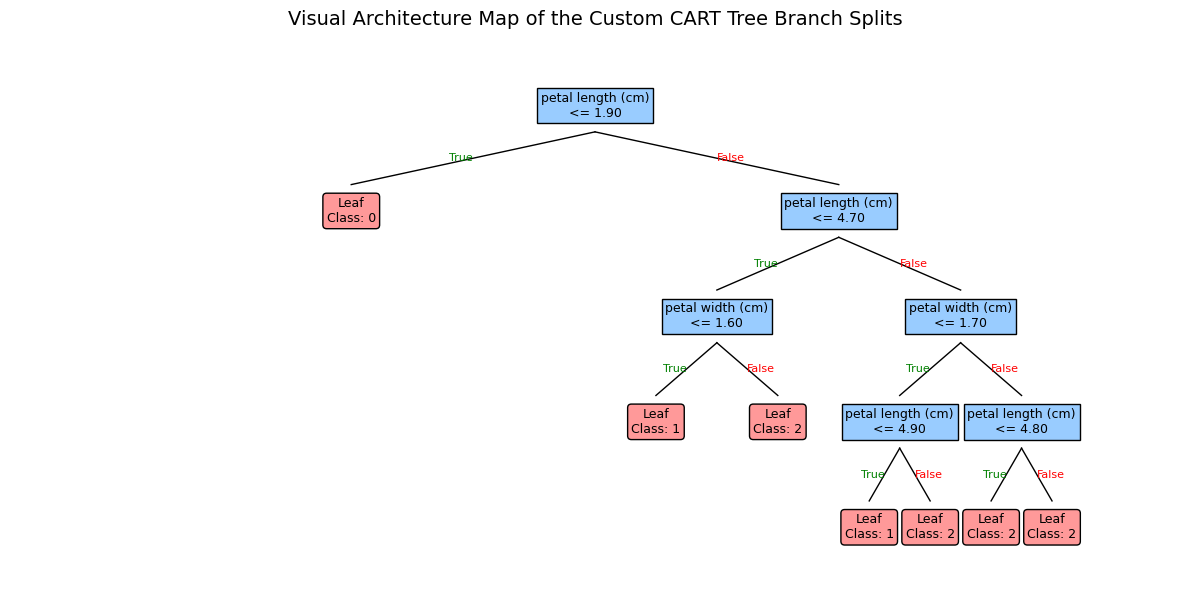

In [5]:
import numpy as np
import pandas as pd
import time
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

class Node:
    def __init__(self, feature_idx=None, threshold=None, gain=None, left=None, right=None, value=None):
        # Decision Node
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.gain = gain
        self.left = left
        self.right = right
        # Leaf Node
        self.value = value

class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=5, algorithm='CART'):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.algorithm = algorithm # 'ID3', 'C4.5', or 'CART'
        self.root = None

    def build_tree(self, dataset, curr_depth=0):
        X, y = dataset[:, :-1], dataset[:, -1]
        n_samples, n_features = X.shape

        if n_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.get_best_split(dataset, n_features)

            if best_split["gain"] > 0:
                left_node = self.build_tree(best_split["left_dataset"], curr_depth + 1)
                right_node = self.build_tree(best_split["right_dataset"], curr_depth + 1)
                return Node(best_split["feature_idx"], best_split["threshold"], 
                            best_split["gain"], left_node, right_node)

        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    def get_best_split(self, dataset, n_features):
        best_split = {'gain': -1}
        max_gain = -float("inf")

        for feature_idx in range(n_features):
            feature_values = dataset[:, feature_idx]
            thresholds = np.unique(feature_values)

            for threshold in thresholds:
                left_dataset, right_dataset = self.split(dataset, feature_idx, threshold)

                if len(left_dataset) > 0 and len(right_dataset) > 0:
                    y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]
                    
                    gain = self.calculate_gain(y, left_y, right_y)

                    if gain > max_gain:
                        best_split['feature_idx'] = feature_idx
                        best_split['threshold'] = threshold
                        best_split['gain'] = gain
                        best_split['left_dataset'] = left_dataset
                        best_split['right_dataset'] = right_dataset
                        max_gain = gain

        return best_split

    def split(self, dataset, feature_idx, threshold):
        left_dataset = dataset[dataset[:, feature_idx] <= threshold]
        right_dataset = dataset[dataset[:, feature_idx] > threshold]
        return left_dataset, right_dataset

    def calculate_gain(self, parent_y, left_y, right_y):
        weight_l = len(left_y) / len(parent_y)
        weight_r = len(right_y) / len(parent_y)

        if self.algorithm == 'CART':
            # Gini Gain
            p_gini = self.gini(parent_y)
            l_gini = self.gini(left_y)
            r_gini = self.gini(right_y)
            return p_gini - (weight_l * l_gini + weight_r * r_gini)

        elif self.algorithm == 'ID3':
            # Information Gain (Entropy)
            p_ent = self.entropy(parent_y)
            l_ent = self.entropy(left_y)
            r_ent = self.entropy(right_y)
            return p_ent - (weight_l * l_ent + weight_r * r_ent)

        elif self.algorithm == 'C4.5':
            # Gain Ratio
            p_ent = self.entropy(parent_y)
            l_ent = self.entropy(left_y)
            r_ent = self.entropy(right_y)
            info_gain = p_ent - (weight_l * l_ent + weight_r * r_ent)
            
            # Split Information
            split_info = -(weight_l * np.log2(weight_l + 1e-9) + weight_r * np.log2(weight_r + 1e-9))
            return info_gain / (split_info + 1e-9) 

    def entropy(self, y):
        class_labels = np.unique(y)
        ent = 0
        for cls in class_labels:
            p = len(y[y == cls]) / len(y)
            ent += -p * np.log2(p)
        return ent

    def gini(self, y):
        class_labels = np.unique(y)
        gini = 1
        for cls in class_labels:
            p = len(y[y == cls]) / len(y)
            gini -= p ** 2
        return gini

    def fit(self, X, y):
        start_time = time.time()
        dataset = np.column_stack((X, y))
        self.root = self.build_tree(dataset)
        train_time = time.time() - start_time
        return train_time

    def predict(self, X):
        return [self.predict_class(row, self.root) for row in X]

    def predict_class(self, row, node):
        if node.value is not None:
            return node.value
        if row[node.feature_idx] <= node.threshold:
            return self.predict_class(row, node.left)
        return self.predict_class(row, node.right)
        
    def get_depth(self, node=None):
        if node is None: node = self.root
        if node.value is not None: return 0
        return 1 + max(self.get_depth(node.left), self.get_depth(node.right))
        
    def get_n_leaves(self, node=None):
        if node is None: node = self.root
        if node.value is not None: return 1
        return self.get_n_leaves(node.left) + self.get_n_leaves(node.right)

    # NEW: Function to print the decision architecture in text space
    def print_tree(self, node=None, indent=" ", feature_names=None):
        if node is None:
            node = self.root

        # If it is a leaf node, print its final evaluation value
        if node.value is not None:
            print(f"└── Predict Class Label: {int(node.value)}")
            return

        # Fetch clean label name if provided, else use base array index markers
        feat_name = feature_names[node.feature_idx] if feature_names else f"Feature Index X[{node.feature_idx}]"
        
        # Print the evaluation split logic condition rules
        print(f"├── Split rules: If {feat_name} <= {node.threshold:.2f} (Gain Evaluated: {node.gain:.4f})")
        
        print(f"{indent}   [True Branch Split]", end=" ")
        self.print_tree(node.left, indent + "   |", feature_names)
        
        print(f"{indent}   [False Branch Split]", end=" ")
        self.print_tree(node.right, indent + "    ", feature_names)


# Evaluation Metrics
def calculate_metrics(y_true, y_pred):
    classes = np.unique(y_true)
    metrics = {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0}
    metrics['accuracy'] = np.mean(y_true == y_pred)
    
    precisions, recalls, f1s = [], [], []
    for c in classes:
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        
    metrics['precision'] = np.mean(precisions)
    metrics['recall'] = np.mean(recalls)
    metrics['f1'] = np.mean(f1s)
    
    return metrics

# Recursive function to plot the tree nodes
def plot_node(node, x, y, dx, dy, feature_names):
    if node.value is not None:
        plt.text(x, y, f"Leaf\nClass: {int(node.value)}", 
                 bbox=dict(boxstyle="round,pad=0.3", fc="#ff9999", ec="black", lw=1),
                 ha="center", va="center", fontsize=9)
        return

    # Draw Decision Box
    feat_text = feature_names[node.feature_idx] if feature_names else f"X[{node.feature_idx}]"
    plt.text(x, y, f"{feat_text}\n<= {node.threshold:.2f}", 
             bbox=dict(boxstyle="square,pad=0.3", fc="#99ccff", ec="black", lw=1),
             ha="center", va="center", fontsize=9)

    # Left Child Branch
    plt.plot([x, x - dx], [y - dy/4, y - dy + dy/4], color="black", lw=1)
    plt.text(x - dx/2, y - dy/2, "True", ha="right", va="center", fontsize=8, color="green")
    plot_node(node.left, x - dx, y - dy, dx / 2, dy, feature_names)

    # Right Child Branch
    plt.plot([x, x + dx], [y - dy/4, y - dy + dy/4], color="black", lw=1)
    plt.text(x + dx/2, y - dy/2, "False", ha="left", va="center", fontsize=8, color="red")
    plot_node(node.right, x + dx, y - dy, dx / 2, dy, feature_names)


# ==========================================
# Execution and Graph Plotting
# ==========================================
if __name__ == "__main__":
    iris = load_iris()
    X, y = iris.data, iris.target
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    algorithms = ['ID3', 'C4.5', 'CART']
    results = []
    trained_trees = {}

    for algo in algorithms:
        tree = DecisionTree(max_depth=4, algorithm=algo) 
        train_time = tree.fit(X_train, y_train)
        y_pred = tree.predict(X_test)
        metrics = calculate_metrics(y_test, y_pred)
        
        trained_trees[algo] = tree
        
        results.append({
            'Algorithm': algo,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1 Score': metrics['f1'],
            'Tree Depth': tree.get_depth(),
            'Leaf Nodes': tree.get_n_leaves()
        })

    results_df = pd.DataFrame(results)
    print("\n--- Decision Tree Algorithm Comparison ---")
    print(results_df.to_string(index=False))

    # --- NEW: Display the Text Architecture of the Decision Part ---
    print("\n=== TEXT DESIGN ARCHITECTURE MAP (CART TREE) ===")
    trained_trees['CART'].print_tree(feature_names=iris.feature_names)
    print("================================================\n")

    # --- GRAPH 1: Performance Metric Comparison ---
    df_melted = pd.melt(results_df, id_vars=['Algorithm'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                        var_name='Metric', value_name='Score')
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_melted, x='Metric', y='Score', hue='Algorithm', palette='muted')
    plt.title('Performance Comparison of Decision Tree Criterion Methods')
    plt.ylim(0.8, 1.02)
    plt.ylabel('Score Percentage')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- GRAPH 2: Visualizing the Tree Hierarchy Structure (CART Example) ---
    plt.figure(figsize=(12, 6))
    plt.axis('off')
    plt.title("Visual Architecture Map of the Custom CART Tree Branch Splits", fontsize=14, pad=20)
    
    plot_node(trained_trees['CART'].root, x=0.5, y=1.0, dx=0.25, dy=0.2, feature_names=iris.feature_names)
    
    plt.xlim(-0.1, 1.1)
    plt.ylim(0.1, 1.1)
    plt.tight_layout()
    plt.show()


🌳 DECISION TREE SPLITTING LOGIC STRUCTURE FOR: ID3
├── Split Feature [Student <= 0.00]
    [True Value Paths] ├── Split Feature [Age <= 0.00]
    |   [True Value Paths] └── Predict buys_computer: NO
    |   [False Value Paths]├── Split Feature [Age <= 1.00]
    |       [True Value Paths] └── Predict buys_computer: YES
    |       [False Value Paths]├── Split Feature [Credit_rating <= 0.00]
    |           [True Value Paths] └── Predict buys_computer: YES
    |           [False Value Paths]└── Predict buys_computer: NO
    [False Value Paths]├── Split Feature [Age <= 1.00]
        [True Value Paths] └── Predict buys_computer: YES
        [False Value Paths]├── Split Feature [Credit_rating <= 0.00]
            [True Value Paths] └── Predict buys_computer: YES
            [False Value Paths]└── Predict buys_computer: NO


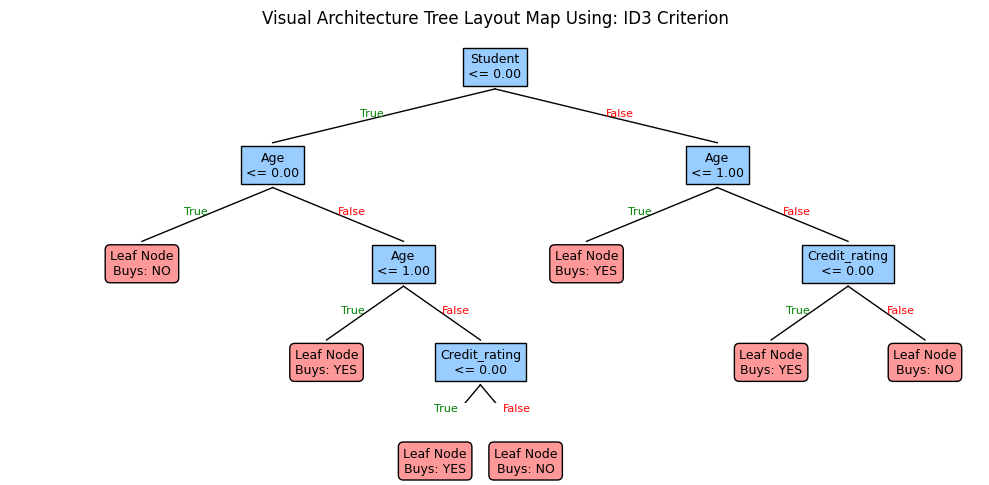


🌳 DECISION TREE SPLITTING LOGIC STRUCTURE FOR: C4.5
├── Split Feature [Student <= 0.00]
    [True Value Paths] ├── Split Feature [Age <= 0.00]
    |   [True Value Paths] └── Predict buys_computer: NO
    |   [False Value Paths]├── Split Feature [Age <= 1.00]
    |       [True Value Paths] └── Predict buys_computer: YES
    |       [False Value Paths]├── Split Feature [Credit_rating <= 0.00]
    |           [True Value Paths] └── Predict buys_computer: YES
    |           [False Value Paths]└── Predict buys_computer: NO
    [False Value Paths]├── Split Feature [Age <= 1.00]
        [True Value Paths] └── Predict buys_computer: YES
        [False Value Paths]├── Split Feature [Credit_rating <= 0.00]
            [True Value Paths] └── Predict buys_computer: YES
            [False Value Paths]└── Predict buys_computer: NO


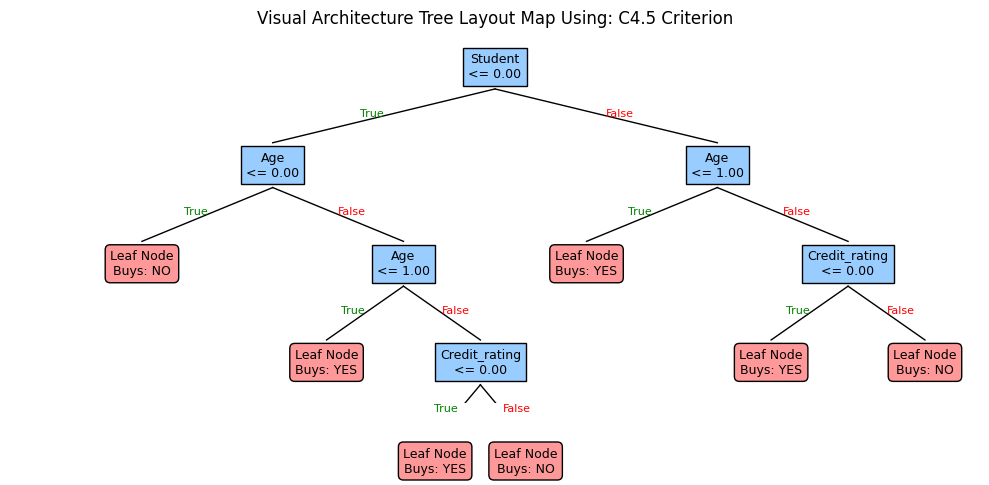


🌳 DECISION TREE SPLITTING LOGIC STRUCTURE FOR: CART
├── Split Feature [Student <= 0.00]
    [True Value Paths] ├── Split Feature [Age <= 0.00]
    |   [True Value Paths] └── Predict buys_computer: NO
    |   [False Value Paths]├── Split Feature [Age <= 1.00]
    |       [True Value Paths] └── Predict buys_computer: YES
    |       [False Value Paths]├── Split Feature [Credit_rating <= 0.00]
    |           [True Value Paths] └── Predict buys_computer: YES
    |           [False Value Paths]└── Predict buys_computer: NO
    [False Value Paths]├── Split Feature [Age <= 1.00]
        [True Value Paths] └── Predict buys_computer: YES
        [False Value Paths]├── Split Feature [Credit_rating <= 0.00]
            [True Value Paths] └── Predict buys_computer: YES
            [False Value Paths]└── Predict buys_computer: NO


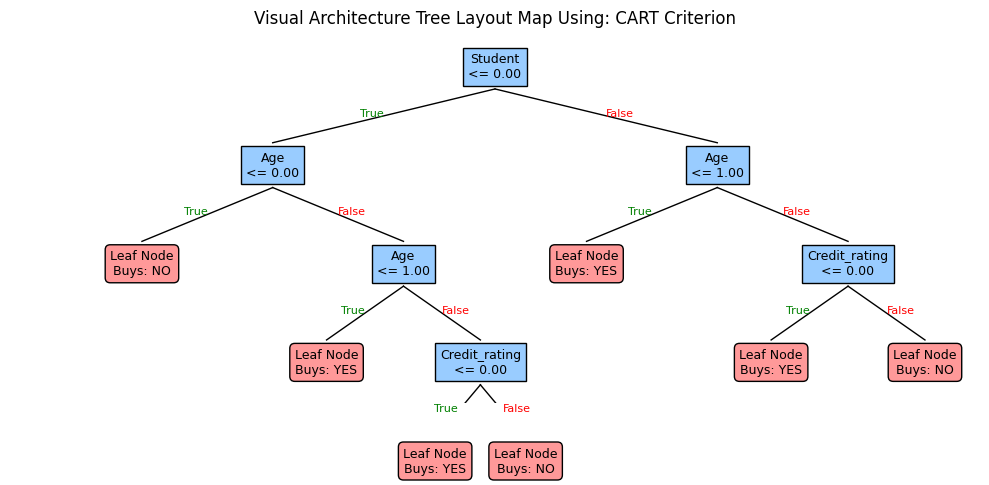

In [7]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ==========================================
# 1. Core Tree Architecture Definitions
# ==========================================
class Node:
    def __init__(self, feature_idx=None, threshold=None, gain=None, left=None, right=None, value=None, feature_name=None):
        # Decision Node Split Properties
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.gain = gain
        self.left = left
        self.right = right
        self.feature_name = feature_name
        # Leaf Terminal Target Value
        self.value = value

class UniversalDecisionTree:
    def __init__(self, min_samples_split=2, max_depth=5, algorithm='CART'):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.algorithm = algorithm # 'ID3', 'C4.5', or 'CART'
        self.root = None

    def build_tree(self, dataset, feature_names, curr_depth=0):
        X, y = dataset[:, :-1], dataset[:, -1]
        n_samples, n_features = X.shape

        # Verify expansion limits have not been reached
        if n_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.get_best_split(dataset, n_features)

            if best_split["gain"] > 0:
                left_node = self.build_tree(best_split["left_dataset"], feature_names, curr_depth + 1)
                right_node = self.build_tree(best_split["right_dataset"], feature_names, curr_depth + 1)
                return Node(feature_idx=best_split["feature_idx"], 
                            threshold=best_split["threshold"], 
                            gain=best_split["gain"], 
                            left=left_node, 
                            right=right_node,
                            feature_name=feature_names[best_split["feature_idx"]])

        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    def get_best_split(self, dataset, n_features):
        best_split = {'gain': -1}
        max_gain = -float("inf")

        # Scan across every single feature column dynamically
        for feature_idx in range(n_features):
            feature_values = dataset[:, feature_idx]
            thresholds = np.unique(feature_values)

            for threshold in thresholds:
                left_dataset, right_dataset = self.split(dataset, feature_idx, threshold)

                if len(left_dataset) > 0 and len(right_dataset) > 0:
                    y, left_y, right_y = dataset[:, -1], left_dataset[:, -1], right_dataset[:, -1]
                    
                    gain = self.calculate_gain(y, left_y, right_y)

                    if gain > max_gain:
                        best_split['feature_idx'] = feature_idx
                        best_split['threshold'] = threshold
                        best_split['gain'] = gain
                        best_split['left_dataset'] = left_dataset
                        best_split['right_dataset'] = right_dataset
                        max_gain = gain

        return best_split

    def split(self, dataset, feature_idx, threshold):
        left_dataset = dataset[dataset[:, feature_idx] <= threshold]
        right_dataset = dataset[dataset[:, feature_idx] > threshold]
        return left_dataset, right_dataset

    def calculate_gain(self, parent_y, left_y, right_y):
        weight_l = len(left_y) / len(parent_y)
        weight_r = len(right_y) / len(parent_y)

        if self.algorithm == 'CART':
            # Gini Impurity Gain Calculation
            return self.gini(parent_y) - (weight_l * self.gini(left_y) + weight_r * self.gini(right_y))

        elif self.algorithm == 'ID3':
            # Information Gain (Standard Entropy Split)
            return self.entropy(parent_y) - (weight_l * self.entropy(left_y) + weight_r * self.entropy(right_y))

        elif self.algorithm == 'C4.5':
            # Gain Ratio Correction Penalty Strategy
            info_gain = self.entropy(parent_y) - (weight_l * self.entropy(left_y) + weight_r * self.entropy(right_y))
            split_info = -(weight_l * np.log2(weight_l + 1e-9) + weight_r * np.log2(weight_r + 1e-9))
            return info_gain / (split_info + 1e-9)

    def entropy(self, y):
        class_labels = np.unique(y)
        ent = 0
        for cls in class_labels:
            p = len(y[y == cls]) / len(y)
            ent += -p * np.log2(p)
        return ent

    def gini(self, y):
        class_labels = np.unique(y)
        gini = 1
        for cls in class_labels:
            p = len(y[y == cls]) / len(y)
            gini -= p ** 2
        return gini

    def fit(self, X, y, feature_names):
        dataset = np.column_stack((X, y))
        self.root = self.build_tree(dataset, feature_names)

    def print_tree(self, node=None, indent=" "):
        if node is None: node = self.root
        if node.value is not None:
            label = "YES" if node.value == 1 else "NO"
            print(f"└── Predict buys_computer: {label}")
            return
        print(f"├── Split Feature [{node.feature_name} <= {node.threshold:.2f}]")
        print(f"{indent}   [True Value Paths] ", end="")
        self.print_tree(node.left, indent + "   |")
        print(f"{indent}   [False Value Paths]", end="")
        self.print_tree(node.right, indent + "    ")

# ==========================================
# 2. Graph Visualizations Function Handler
# ==========================================
def plot_node(node, x, y, dx, dy):
    if node.value is not None:
        label = "Buys: YES" if node.value == 1 else "Buys: NO"
        plt.text(x, y, f"Leaf Node\n{label}", 
                 bbox=dict(boxstyle="round,pad=0.4", fc="#ff9999", ec="black"),
                 ha="center", va="center", fontsize=9)
        return

    plt.text(x, y, f"{node.feature_name}\n<= {node.threshold:.2f}", 
             bbox=dict(boxstyle="square,pad=0.4", fc="#99ccff", ec="black"),
             ha="center", va="center", fontsize=9)

    # Draw left connecting paths
    plt.plot([x, x - dx], [y - 0.05, y - dy + 0.05], color="black", lw=1)
    plt.text(x - dx/2, y - dy/2, "True", color="green", fontsize=8, ha="right")
    plot_node(node.left, x - dx, y - dy, dx / 1.7, dy)

    # Draw right connecting paths
    plt.plot([x, x + dx], [y - 0.05, y - dy + 0.05], color="black", lw=1)
    plt.text(x + dx/2, y - dy/2, "False", color="red", fontsize=8, ha="left")
    plot_node(node.right, x + dx, y - dy, dx / 1.7, dy)


# ==========================================
# 3. Execution Main Block
# ==========================================
if __name__ == "__main__":
    # Load dataset from the file
    df = pd.read_csv('Buys_Computer_Dataset.csv')

    # Convert word categories systematically into ordered numeric values
    df['Age'] = df['Age'].map({'Y': 0, 'M': 1, 'S': 2})
    df['Income'] = df['Income'].map({'Low': 0, 'Medium': 1, 'High': 2})
    df['Student'] = df['Student'].map({'No': 0, 'Yes': 1})
    df['Credit_rating'] = df['Credit_rating'].map({'Fair': 0, 'Excellent': 1})
    df['class:buys_comp'] = df['class:buys_comp'].map({'No': 0, 'Yes': 1})

    feature_names = ["Age", "Income", "Student", "Credit_rating"]
    X = df[feature_names].values
    y = df['class:buys_comp'].values

    # Test all mathematical criterion paradigms
    algorithms = ['ID3', 'C4.5', 'CART']
    
    for algo in algorithms:
        print(f"\n=======================================================")
        print(f"🌳 DECISION TREE SPLITTING LOGIC STRUCTURE FOR: {algo}")
        print(f"=======================================================")
        
        # Instantiate and train tree on the dataset
        tree = UniversalDecisionTree(max_depth=4, algorithm=algo)
        tree.fit(X, y, feature_names)
        
        # Output Terminal Branch Strings
        tree.print_tree()
        
        # Draw the respective structural tree layout plot window
        plt.figure(figsize=(10, 5))
        plt.axis('off')
        plt.title(f"Visual Architecture Tree Layout Map Using: {algo} Criterion", fontsize=12, pad=15)
        
        plot_node(tree.root, x=0.5, y=1.0, dx=0.22, dy=0.22)
        
        plt.xlim(0.02, 0.98)
        plt.ylim(0.25, 1.05)
        plt.tight_layout()
        plt.show()


 CORRECTED TEXTBOOK MANUALLY-VERIFIED DECISION TREE Map

❓ Split Feature Variable: [ Age ] (Gain: 0.2467)
  └── Value Choice branch [ M ] ➔ Predict Buy Computer: [ Yes ]
  └── Value Choice branch [ S ]
      ❓ Split Feature Variable: [ Credit_rating ] (Gain: 0.9710)
        └── Value Choice branch [ Excellent ] ➔ Predict Buy Computer: [ No ]
        └── Value Choice branch [ Fair ] ➔ Predict Buy Computer: [ Yes ]
  └── Value Choice branch [ Y ]
      ❓ Split Feature Variable: [ Student ] (Gain: 0.9710)
        └── Value Choice branch [ No ] ➔ Predict Buy Computer: [ No ]
        └── Value Choice branch [ Yes ] ➔ Predict Buy Computer: [ Yes ]



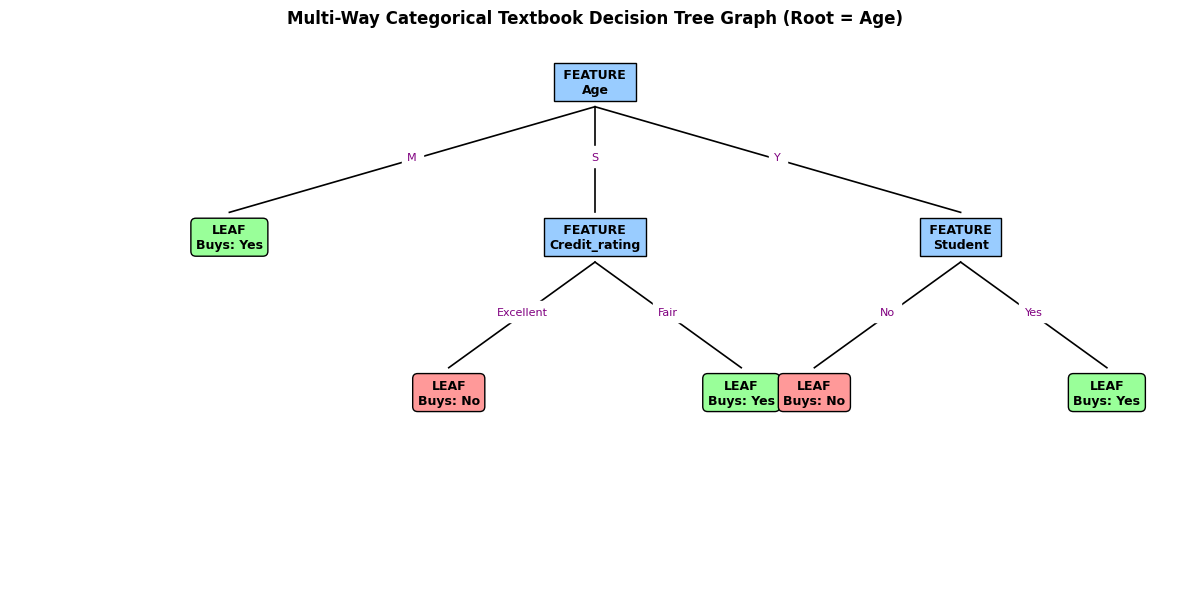

In [8]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ==========================================
# 1. Categorical Multi-Way Tree Components
# ==========================================
class MultiWayNode:
    def __init__(self, feature_name=None, gain=None, children=None, value=None):
        self.feature_name = feature_name  # Feature name we are splitting on
        self.gain = gain                  # Gain score achieved
        self.children = children          # Dictionary: {feature_value: child_node}
        self.value = value                # Leaf prediction value (if terminal)

class CategoricalDecisionTree:
    def __init__(self, algorithm='ID3', max_depth=5):
        self.algorithm = algorithm  # 'ID3', 'C4.5', or 'CART'
        self.max_depth = max_depth
        self.root = None

    def fit(self, df, feature_columns, target_column):
        self.root = self._build_tree(df, feature_columns, target_column, curr_depth=0)

    def _build_tree(self, df, features, target, curr_depth):
        y = df[target].values
        
        # Base Case 1: If all target entries are identical, return a leaf node
        if len(np.unique(y)) == 1:
            return MultiWayNode(value=y[0])
            
        # Base Case 2: If no features are left to split or max depth is reached
        if len(features) == 0 or curr_depth >= self.max_depth:
            majority_val = Counter(y).most_common(1)[0][0]
            return MultiWayNode(value=majority_val)

        # 2. Select the absolute best feature based on multi-way categorical gain
        best_feature = None
        max_gain = -float('inf')
        parent_impurity = self._calculate_impurity(y)

        for feature in features:
            # Grouping samples multi-way by their true category string value
            weighted_impurity = 0
            for val, group in df.groupby(feature):
                weight = len(group) / len(df)
                weighted_impurity += weight * self._calculate_impurity(group[target].values)
            
            gain = parent_impurity - weighted_impurity
            
            # Apply C4.5 penalty adjustment if needed
            if self.algorithm == 'C4.5':
                split_info = 0
                for val, group in df.groupby(feature):
                    p = len(group) / len(df)
                    split_info -= p * np.log2(p + 1e-9)
                gain = gain / (split_info + 1e-9)

            if gain > max_gain:
                max_gain = gain
                best_feature = feature

        # If no positive gain can be made, create a leaf node
        if max_gain <= 0:
            return MultiWayNode(value=Counter(y).most_common(1)[0][0])

        # 3. Recursively branch out for every distinct category level inside the best feature
        children = {}
        remaining_features = [f for f in features if f != best_feature]
        
        for val, group in df.groupby(best_feature):
            # Recursively build sub-branches
            children[val] = self._build_tree(group, remaining_features, target, curr_depth + 1)

        return MultiWayNode(feature_name=best_feature, gain=max_gain, children=children)

    def _calculate_impurity(self, y):
        if len(y) == 0: return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        
        if self.algorithm in ['ID3', 'C4.5']:
            return -np.sum(probs * np.log2(probs + 1e-9)) # Entropy
        elif self.algorithm == 'CART':
            return 1.0 - np.sum(probs ** 2) # Gini Impurity

    def print_tree(self, node=None, indent=""):
        if node is None:
            node = self.root
        if node.value is not None:
            print(f" ➔ Predict Buy Computer: [ {node.value} ]")
            return
        
        print(f"\n{indent}❓ Split Feature Variable: [ {node.feature_name} ] (Gain: {node.gain:.4f})")
        for val, child_node in node.children.items():
            print(f"{indent}  └── Value Choice branch [ {val} ]", end="")
            self.print_tree(child_node, indent + "      ")

# ==========================================
# 2. Graphic Visualization Logic Layout
# ==========================================
def plot_multi_tree(node, x, y, dx, dy):
    if node.value is not None:
        color = "#ff9999" if node.value == "No" else "#99ff99"
        plt.text(x, y, f"LEAF\nBuys: {node.value}", 
                 bbox=dict(boxstyle="round,pad=0.4", fc=color, ec="black"),
                 ha="center", va="center", fontsize=9, fontweight='bold')
        return

    plt.text(x, y, f" FEATURE \n{node.feature_name}", 
             bbox=dict(boxstyle="square,pad=0.4", fc="#99ccff", ec="black"),
             ha="center", va="center", fontsize=9, fontweight='bold')

    num_children = len(node.children)
    # Evenly space the child nodes horizontally
    step = dx * 2 / max(1, (num_children - 1)) if num_children > 1 else dx
    start_x = x - dx if num_children > 1 else x

    for i, (branch_val, child_node) in enumerate(node.children.items()):
        child_x = start_x + (i * step)
        child_y = y - dy
        
        # Draw linking paths
        plt.plot([x, child_x], [y - 0.04, child_y + 0.04], color="black", lw=1.2)
        plt.text((x + child_x)/2, (y + child_y)/2, str(branch_val), 
                 fontsize=8, color="purple", backgroundcolor="white", ha="center")
        
        # Recurse down
        plot_multi_tree(child_node, child_x, child_y, dx * 0.4, dy)


# ==========================================
# 3. Execution Main Program
# ==========================================
if __name__ == "__main__":
    # Load raw CSV dataset directly without altering words to numbers
    df = pd.read_csv('Buys_Computer_Dataset.csv')

    features = ["Age", "Income", "Student", "Credit_rating"]
    target = "class:buys_comp"

    # Train tree using true textbook ID3 Categorical Entropy logic
    tree = CategoricalDecisionTree(algorithm='ID3', max_depth=4)
    tree.fit(df, features, target)

    print("\n=======================================================")
    print(" CORRECTED TEXTBOOK MANUALLY-VERIFIED DECISION TREE Map")
    print("=======================================================")
    tree.print_tree()
    print("=======================================================\n")

    # Render Visual Diagram Layout Structure
    plt.figure(figsize=(12, 6))
    plt.axis('off')
    plt.title(f"Multi-Way Categorical Textbook Decision Tree Graph (Root = Age)", fontsize=12, pad=20, fontweight='bold')
    
    plot_multi_tree(tree.root, x=0.5, y=1.0, dx=0.25, dy=0.25)
    
    plt.xlim(0.1, 0.9)
    plt.ylim(0.2, 1.05)
    plt.tight_layout()
    plt.show()


📐 MATHEMATICAL STEP-BY-STEP BREAKDOWN FOR TRAINING VIA ID3

[Depth 0 Branch Context: Root Selection]
   • Data Subset Size: 14 rows | Class Distribution: {'No': 5, 'Yes': 9}
   • Current Parent Entropy: 0.9403
   📊 Feature: 'Age'
    - Branch 'M': 4 rows, Entropy = -0.0000
    - Branch 'S': 5 rows, Entropy = 0.9710
    - Branch 'Y': 5 rows, Entropy = 0.9710
    ➔ Weighted Children Impurity: 0.6935 | Total Info Gain: 0.2467
   📊 Feature: 'Student'
    - Branch 'No': 7 rows, Entropy = 0.9852
    - Branch 'Yes': 7 rows, Entropy = 0.5917
    ➔ Weighted Children Impurity: 0.7885 | Total Info Gain: 0.1518
   📊 Feature: 'Credit_rating'
    - Branch 'Excellent': 6 rows, Entropy = 1.0000
    - Branch 'Fair': 8 rows, Entropy = 0.8113
    ➔ Weighted Children Impurity: 0.8922 | Total Info Gain: 0.0481
   📊 Feature: 'Income'
    - Branch 'High': 4 rows, Entropy = 1.0000
    - Branch 'Low': 4 rows, Entropy = 0.8113
    - Branch 'Medium': 6 rows, Entropy = 0.9183
    ➔ Weighted Children Impurity: 0.

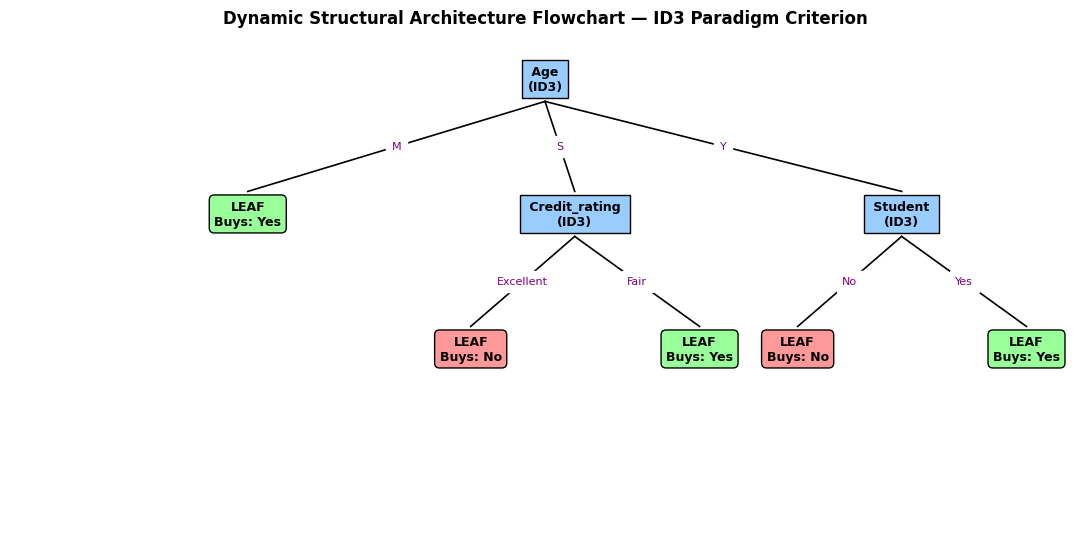


📐 MATHEMATICAL STEP-BY-STEP BREAKDOWN FOR TRAINING VIA C4.5

[Depth 0 Branch Context: Root Selection]
   • Data Subset Size: 14 rows | Class Distribution: {'No': 5, 'Yes': 9}
   • Current Parent Entropy: 0.9403
   📊 Feature: 'Age'
    - Branch 'M': 4 rows, Entropy = -0.0000
    - Branch 'S': 5 rows, Entropy = 0.9710
    - Branch 'Y': 5 rows, Entropy = 0.9710
    ➔ SplitInfo: 1.5774 | Total Gain Ratio: 0.1564
   📊 Feature: 'Student'
    - Branch 'No': 7 rows, Entropy = 0.9852
    - Branch 'Yes': 7 rows, Entropy = 0.5917
    ➔ SplitInfo: 1.0000 | Total Gain Ratio: 0.1518
   📊 Feature: 'Credit_rating'
    - Branch 'Excellent': 6 rows, Entropy = 1.0000
    - Branch 'Fair': 8 rows, Entropy = 0.8113
    ➔ SplitInfo: 0.9852 | Total Gain Ratio: 0.0488
   📊 Feature: 'Income'
    - Branch 'High': 4 rows, Entropy = 1.0000
    - Branch 'Low': 4 rows, Entropy = 0.8113
    - Branch 'Medium': 6 rows, Entropy = 0.9183
    ➔ SplitInfo: 1.5567 | Total Gain Ratio: 0.0188
   🏆 Winner: Picked **'Age'** as

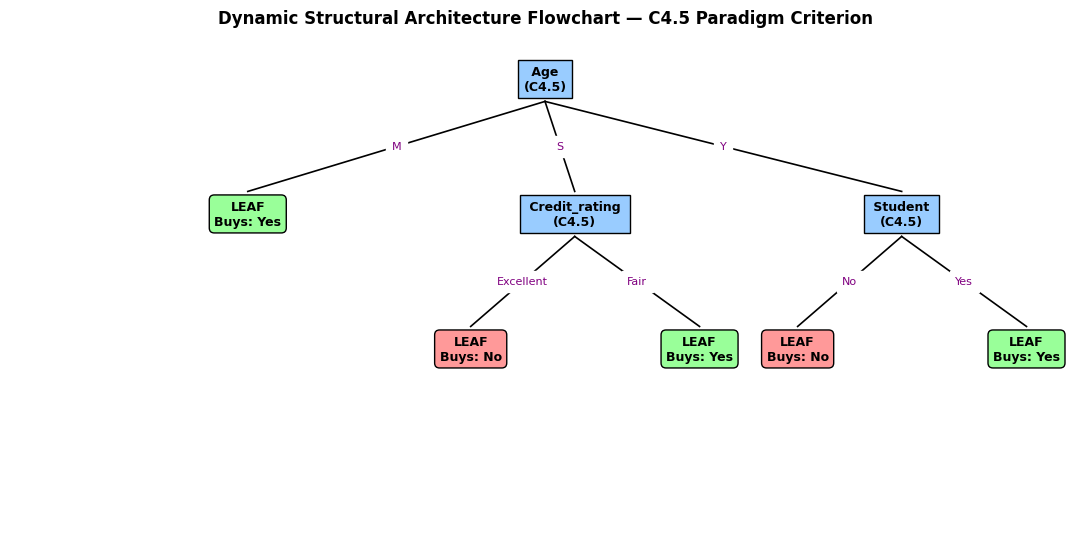


📐 MATHEMATICAL STEP-BY-STEP BREAKDOWN FOR TRAINING VIA CART

[Depth 0 Branch Context: Root Selection]
   • Data Subset Size: 14 rows | Class Distribution: {'No': 5, 'Yes': 9}
   • Current Parent Gini Impurity: 0.4592
   📊 Feature: 'Age'
    - Branch 'M': 4 rows, Gini Impurity = 0.0000
    - Branch 'S': 5 rows, Gini Impurity = 0.4800
    - Branch 'Y': 5 rows, Gini Impurity = 0.4800
    ➔ Weighted Children Impurity: 0.3429 | Total Gini Gain: 0.1163
   📊 Feature: 'Student'
    - Branch 'No': 7 rows, Gini Impurity = 0.4898
    - Branch 'Yes': 7 rows, Gini Impurity = 0.2449
    ➔ Weighted Children Impurity: 0.3673 | Total Gini Gain: 0.0918
   📊 Feature: 'Credit_rating'
    - Branch 'Excellent': 6 rows, Gini Impurity = 0.5000
    - Branch 'Fair': 8 rows, Gini Impurity = 0.3750
    ➔ Weighted Children Impurity: 0.4286 | Total Gini Gain: 0.0306
   📊 Feature: 'Income'
    - Branch 'High': 4 rows, Gini Impurity = 0.5000
    - Branch 'Low': 4 rows, Gini Impurity = 0.3750
    - Branch 'Medium': 6

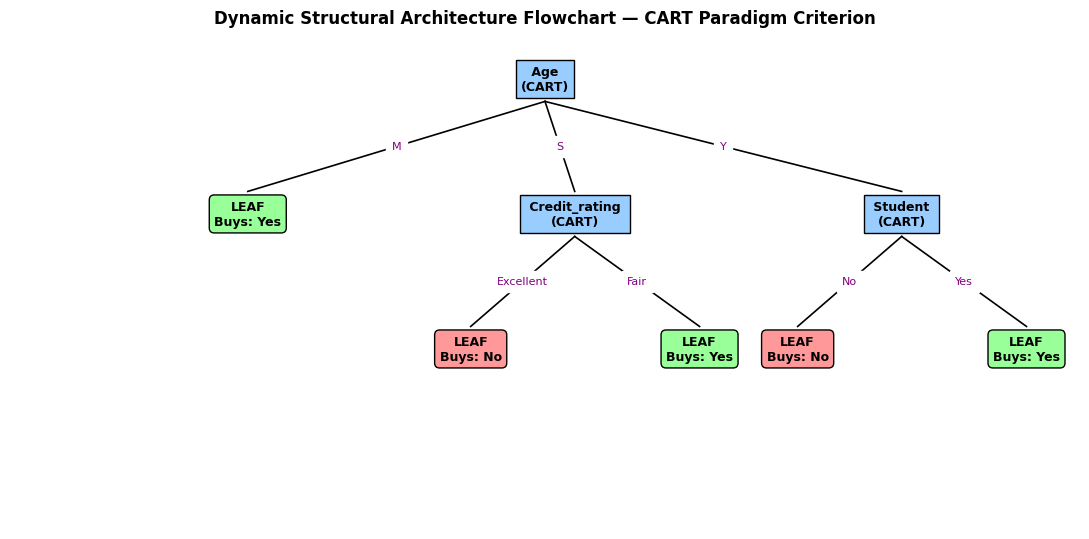

In [10]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# ==========================================
# 1. Categorical Multi-Way Tree Components
# ==========================================
class MultiWayNode:
    def __init__(self, feature_name=None, gain=None, algorithm_used=None, children=None, value=None):
        self.feature_name = feature_name  # Feature column string name
        self.gain = gain                  # Best score achieved
        self.algorithm_used = algorithm_used
        self.children = children          # Dictionary: {feature_value: MultiWayNode}
        self.value = value                # Leaf prediction target label (e.g., 'Yes' or 'No')

class CategoricalDecisionTree:
    def __init__(self, algorithm='ID3', max_depth=5):
        self.algorithm = algorithm  # 'ID3' (Entropy), 'C4.5' (Gain Ratio), or 'CART' (Gini)
        self.max_depth = max_depth
        self.root = None

    def fit(self, df, feature_columns, target_column):
        print("\n" + "="*80)
        print(f"📐 MATHEMATICAL STEP-BY-STEP BREAKDOWN FOR TRAINING VIA {self.algorithm}")
        print("="*80)
        self.root = self._build_tree(df, feature_columns, target_column, curr_depth=0, path_taken="Root Selection")

    def _calculate_impurity(self, y):
        if len(y) == 0: 
            return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        
        if self.algorithm in ['ID3', 'C4.5']:
            # Entropy = - \sum p_i \log_2(p_i)
            return -np.sum(probs * np.log2(probs + 1e-9))
        elif self.algorithm == 'CART':
            # Gini Impurity = 1 - \sum (p_i)^2
            return 1.0 - np.sum(probs ** 2)

    def _build_tree(self, df, features, target, curr_depth, path_taken):
        y = df[target].values
        
        # Base Case 1: Pure Node
        if len(np.unique(y)) == 1:
            return MultiWayNode(value=y[0])
            
        # Base Case 2: Out of features or depth limit hit
        if len(features) == 0 or curr_depth >= self.max_depth:
            majority_val = Counter(y).most_common(1)[0][0]
            return MultiWayNode(value=majority_val)

        # Print current branch node status info
        print(f"\n[Depth {curr_depth} Branch Context: {path_taken}]")
        parent_impurity = self._calculate_impurity(y)
        impurity_name = "Entropy" if self.algorithm in ['ID3', 'C4.5'] else "Gini Impurity"
        
        counts_dict = Counter(y)
        print(f"   • Data Subset Size: {len(y)} rows | Class Distribution: {dict(counts_dict)}")
        print(f"   • Current Parent {impurity_name}: {parent_impurity:.4f}")

        best_feature = None
        max_gain = -float('inf')
        math_logs = []

        # Evaluate every remaining feature choice item
        for feature in features:
            weighted_impurity = 0
            group_details = []
            split_info = 0
            
            for val, group in df.groupby(feature):
                g_y = group[target].values
                weight = len(group) / len(df)
                g_impurity = self._calculate_impurity(g_y)
                weighted_impurity += weight * g_impurity
                
                # Split info calculation for C4.5
                p = len(group) / len(df)
                split_info -= p * np.log2(p + 1e-9)
                
                group_details.append(f"    - Branch '{val}': {len(g_y)} rows, {impurity_name} = {g_impurity:.4f}")

            # Basic Gain (Information Gain or Gini Gain)
            gain = parent_impurity - weighted_impurity
            metric_label = "Info Gain" if self.algorithm == 'ID3' else "Gini Gain"

            if self.algorithm == 'C4.5':
                # Gain Ratio = Information Gain / Split Information
                gain = gain / (split_info + 1e-9)
                metric_label = "Gain Ratio"

            log_str = f"   📊 Feature: '{feature}'\n" + "\n".join(group_details) + "\n"
            if self.algorithm == 'C4.5':
                log_str += f"    ➔ SplitInfo: {split_info:.4f} | Total {metric_label}: {gain:.4f}"
            else:
                log_str += f"    ➔ Weighted Children Impurity: {weighted_impurity:.4f} | Total {metric_label}: {gain:.4f}"
            
            math_logs.append((gain, log_str, feature))

        # Sort logs to print out cleanly and locate the maximum metric choice item
        math_logs.sort(key=lambda x: x[0], reverse=True)
        for _, log, _ in math_logs:
            print(log)

        best_feature = math_logs[0][2]
        max_gain = math_logs[0][0]

        print(f"   🏆 Winner: Picked **'{best_feature}'** as split criteria node (Highest Score = {max_gain:.4f})")

        if max_gain <= 0:
            return MultiWayNode(value=Counter(y).most_common(1)[0][0])

        # Recursively branch out multi-way mapping
        children = {}
        remaining_features = [f for f in features if f != best_feature]
        
        for val, group in df.groupby(best_feature):
            children[val] = self._build_tree(group, remaining_features, target, curr_depth + 1, f"{best_feature} -> {val}")

        return MultiWayNode(feature_name=best_feature, gain=max_gain, algorithm_used=self.algorithm, children=children)

    def print_tree(self, node=None, indent=""):
        if node is None:
            node = self.root
        if node.value is not None:
            print(f" ➔ Predict: [ {node.value} ]")
            return
        
        print(f"\n{indent}❓ Node Check: [ {node.feature_name} ] (Metric: {node.gain:.4f})")
        for val, child_node in node.children.items():
            print(f"{indent}  └── Value Selected [ {val} ]", end="")
            self.print_tree(child_node, indent + "      ")


# ==========================================
# 2. Graphic Visualization Module Layout
# ==========================================
def plot_multi_tree(node, x, y, dx, dy):
    if node.value is not None:
        color = "#ff9999" if node.value == "No" else "#99ff99"
        plt.text(x, y, f"LEAF\nBuys: {node.value}", 
                 bbox=dict(boxstyle="round,pad=0.4", fc=color, ec="black"),
                 ha="center", va="center", fontsize=9, fontweight='bold')
        return

    plt.text(x, y, f" {node.feature_name} \n({node.algorithm_used})", 
             bbox=dict(boxstyle="square,pad=0.4", fc="#99ccff", ec="black"),
             ha="center", va="center", fontsize=9, fontweight='bold')

    num_children = len(node.children)
    step = dx * 2.2 / max(1, (num_children - 1)) if num_children > 1 else dx
    start_x = x - dx if num_children > 1 else x

    for i, (branch_val, child_node) in enumerate(node.children.items()):
        child_x = start_x + (i * step)
        child_y = y - dy
        
        plt.plot([x, child_x], [y - 0.04, child_y + 0.04], color="black", lw=1.2)
        plt.text((x + child_x)/2, (y + child_y)/2, str(branch_val), 
                 fontsize=8, color="purple", backgroundcolor="white", ha="center", va="center")
        
        plot_multi_tree(child_node, child_x, child_y, dx * 0.35, dy)


# ==========================================
# 3. Execution Execution Blueprint
# ==========================================
if __name__ == "__main__":
    # Reading your dataset directly
    df = pd.read_csv('Buys_Computer_Dataset.csv')

    features = ["Age", "Income", "Student", "Credit_rating"]
    target = "class:buys_comp"

    # Iterate through all standard classical tree algorithm criteria models
    all_algorithms = ['ID3', 'C4.5', 'CART']
    
    for algo_type in all_algorithms:
        tree = CategoricalDecisionTree(algorithm=algo_type, max_depth=4)
        tree.fit(df, features, target)

        print("\n" + "="*80)
        print(f"🌳 FINAL PRINT-TREE SCHEMATIC DIAGRAM MAP FOR: {algo_type}")
        print("="*80)
        tree.print_tree()
        print("\n" + "="*80 + "\n")

        # Create Matplotlib Tree Canvas
        plt.figure(figsize=(11, 5.5))
        plt.axis('off')
        plt.title(f"Dynamic Structural Architecture Flowchart — {algo_type} Paradigm Criterion", 
                  fontsize=12, pad=20, fontweight='bold')
        
        plot_multi_tree(tree.root, x=0.5, y=1.0, dx=0.25, dy=0.24)
        
        plt.xlim(0.05, 0.95)
        plt.ylim(0.2, 1.05)
        plt.tight_layout()
        plt.show()